In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Step 2: Load and Preprocess Fashion-MNIST
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


In [ ]:
#Step 3: Function to Build DNN Model
def build_model(reg_type=None, l1=0.0, l2=0.0):
    if reg_type == "l1":
        reg = regularizers.l1(l1)
    elif reg_type == "l2":
        reg = regularizers.l2(l2)
    elif reg_type == "elastic":
        reg = regularizers.l1_l2(l1=l1, l2=l2)
    else:
        reg = None

    model = models.Sequential([
        layers.Dense(512, activation='relu', kernel_regularizer=reg, input_shape=(784,)),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# Step 4: Train Models with Different Regularization
EPOCHS = 20
BATCH_SIZE = 128

In [ ]:
# 1. No Regularization
model_none = build_model()
history_none = model_none.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7609 - loss: 0.6835 - val_accuracy: 0.8572 - val_loss: 0.4002
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8623 - loss: 0.3700 - val_accuracy: 0.8722 - val_loss: 0.3480
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8788 - loss: 0.3312 - val_accuracy: 0.8816 - val_loss: 0.3279
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8846 - loss: 0.3096 - val_accuracy: 0.8817 - val_loss: 0.3232
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8955 - loss: 0.2799 - val_accuracy: 0.8699 - val_loss: 0.3535
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8992 - loss: 0.2680 - val_accuracy: 0.8873 - val_loss: 0.3171
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9035 - loss: 0.2516 - val_accuracy: 0.8763 - val_loss: 0.3493
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9034 - loss: 0.2478 - val_ac

In [ ]:
# 2. L1 Regularization
model_l1 = build_model(reg_type="l1", l1=0.001)
history_l1 = model_l1.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7097 - loss: 9.0655 - val_accuracy: 0.7690 - val_loss: 1.6256
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7914 - loss: 1.4330 - val_accuracy: 0.7713 - val_loss: 1.1695
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8123 - loss: 1.0555 - val_accuracy: 0.8198 - val_loss: 0.9362
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8179 - loss: 0.9216 - val_accuracy: 0.8118 - val_loss: 0.8997
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8214 - loss: 0.8628 - val_accuracy: 0.8006 - val_loss: 0.8613
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8254 - loss: 0.8188 - val_accuracy: 0.8253 - val_loss: 0.8018
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8333 - loss: 0.7842 - val_accuracy: 0.8377 - val_loss: 0.7558
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.8333 - loss: 0.7637 - val_ac

In [ ]:
#3. L2 Regularization
model_l2 = build_model(reg_type="l2", l2=0.001)
history_l2 = model_l2.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7537 - loss: 1.4545 - val_accuracy: 0.8248 - val_loss: 0.8611
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8453 - loss: 0.7588 - val_accuracy: 0.8502 - val_loss: 0.6631
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8572 - loss: 0.6220 - val_accuracy: 0.8525 - val_loss: 0.5891
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8688 - loss: 0.5393 - val_accuracy: 0.8612 - val_loss: 0.5409
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8698 - loss: 0.5078 - val_accuracy: 0.8558 - val_loss: 0.5246
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8771 - loss: 0.4713 - val_accuracy: 0.8512 - val_loss: 0.5145
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8701 - loss: 0.4663 - val_accuracy: 0.8763 - val_loss: 0.4573
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8768 - loss: 0.4456 - val_acc

In [ ]:
# 4. Elastic Net (L1 + L2)
model_elastic = build_model(reg_type="elastic", l1=0.0005, l2=0.0005)
history_elastic = model_elastic.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7327 - loss: 5.8557 - val_accuracy: 0.8068 - val_loss: 1.5083
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8127 - loss: 1.3500 - val_accuracy: 0.8182 - val_loss: 1.0442
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8231 - loss: 0.9851 - val_accuracy: 0.8355 - val_loss: 0.8481
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8303 - loss: 0.8387 - val_accuracy: 0.8366 - val_loss: 0.7724
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8354 - loss: 0.7645 - val_accuracy: 0.8419 - val_loss: 0.7200
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8417 - loss: 0.7095 - val_accuracy: 0.8471 - val_loss: 0.6859
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8449 - loss: 0.6764 - val_accuracy: 0.8492 - val_loss: 0.6622
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8473 - loss: 0.6576 - val_a

#### Step 5: Plot Training vs Validation Loss

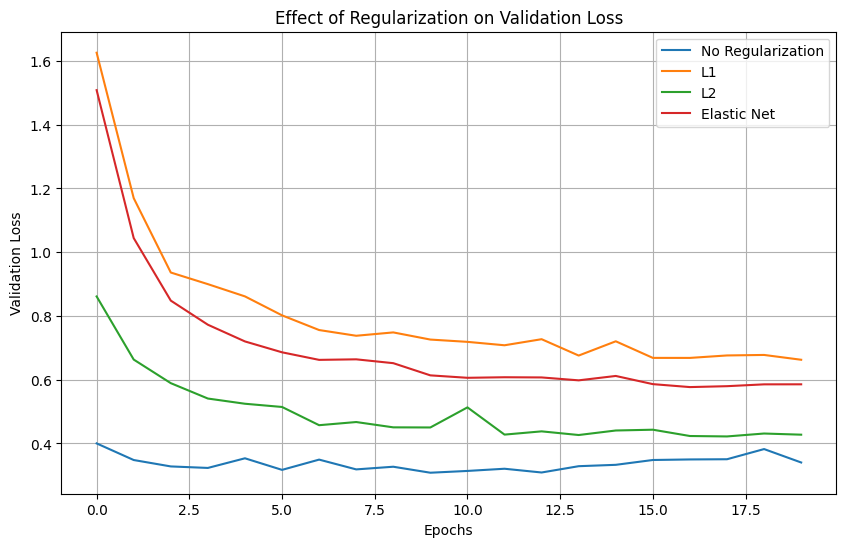

In [ ]:
def plot_loss(histories, labels):
    plt.figure(figsize=(10,6))
    for history, label in zip(histories, labels):
        plt.plot(history.history['val_loss'], label=label)
    plt.xlabel("Epochs")
    plt.ylabel("Validation Loss")
    plt.title("Effect of Regularization on Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(
    [history_none, history_l1, history_l2, history_elastic],
    ["No Regularization", "L1", "L2", "Elastic Net"]
)


####Step 6: Evaluate on Test Data

In [ ]:
models_list = [
    ("No Reg", model_none),
    ("L1", model_l1),
    ("L2", model_l2),
    ("Elastic Net", model_elastic)
]

for name, model in models_list:
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} → Test Accuracy: {acc:.4f}")


No Reg → Test Accuracy: 0.8900
L1 → Test Accuracy: 0.8309
L2 → Test Accuracy: 0.8716
Elastic Net → Test Accuracy: 0.8396
